# DPAC Clustering

Logan Wong

law3082

Load the embeddings

DPAC did pretraining to learn features from images.
But I'm not using images, I'm using Tweets.
The Tweets were embedded into vectors using a pretrained LLM, all-mpnet-base-v2, which follows the SBERT architecture.

Do clustering using DPAC

Neither paper split their data into train/valid/test
So neither paper did hyperparameter tuning.

But, the DPAC paper had these hyperparameters:
Weight exponent, m: 1.03
Temperature, tau: 0.5
Adam Optimizer LR: 0.0001
1000 epochs for the pre-training step
200 epochs for the clustering step
Cluster number, K: predefined for the algorithms…

Incremental Clustering for Event Detection on Twitter paper had a dynamic incremental learning algo that did NOT need T, the # of clusters, predefined.

DPAC DID need K, the # of clusters, to be predefined.

In [1]:
import sys
import os

# Add the DPAC program folder to path
dpac_path = '/home/stu5/s5/law3082/Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/'
if dpac_path not in sys.path:
    sys.path.append(dpac_path)

In [2]:
import pandas as pd
import time

import argparse
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import itertools

from models import Network 
from contrastive_loss import InfonceLoss
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Evaluation metrics
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score


In [3]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

# Load Embeddings

In [5]:
embeddings_raw = np.load('data/event2012_embeddings.npy')
# Convert to a Float Tensor & move to GPU
embeddings = torch.from_numpy(embeddings_raw).float().to(device)

# Load the metadata to track tweet IDs
metadata = pd.read_csv('data/event2012_metadata.csv')

print(f"Loaded {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded 68841 embeddings with dimension 768


In [6]:
# This class is based on ContrastiveLearningDataset, found in 
# /Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/data/
class TwitterVectorDataset(Dataset):
    def __init__(self, vecs):
        self.vecs = vecs
        
    def __len__(self):
        return len(self.vecs)

    def __getitem__(self, idx):
        x = self.vecs[idx]
        # DPAC expects (weak, strong, ori). 
        # "views" are simulated by adding 1% and 5% noise to the vectors.
        weak = x + torch.randn_like(x) * 0.01
        strong = x + torch.randn_like(x) * 0.05
        return (weak, strong, x), 0 # 0 is a placeholder label

In [7]:
# Initialize loader
dataset = TwitterVectorDataset(embeddings)
batch_size = 256
ins_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# a mismatch between batch size and the number of tweets in the dataset
# total number of tweets isn't perfectly divisible by 256, the very last batch is smaller (a "partial batch")
# tell DataLoader to ignore the last tiny leftover piece of data
# DataLoader drops the "partial batch" 

In [8]:
# Define a Backbone for vectors
# original DPAC repo uses ResNet (which is for images)
# This is an MLP backbone to handle Twitter vectors
class TwitterBackbone(nn.Module):
    def __init__(self, input_dim=768, rep_dim=128):
        super().__init__()
        self.rep_dim = rep_dim # The Network class NEEDS this attribute
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, rep_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

In [9]:
# 768
input_dim = embeddings.shape[1]

# DPAC 'z' space dimension
feature_dim = 128    

# target number of clusters (events) aka class_num
num_events = 503

# Training

In [13]:
def train_model(model, ins_loader, optimizer, criterion, scaler, device, m):
    model.train()
    loss_epoch = {'loss1': 0, 'loss2': 0}
    
    for step, ((weak, strong, ori), _) in enumerate(ins_loader):
        # Move all versions of the tweet vector to the GPU
        weak = weak.to(device)
        strong = strong.to(device)
        ori = ori.to(device)
        
        # Concatenate weak and strong for contrastive learning
        img = torch.cat((weak, strong), dim=0)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            # Forward pass
            z, p1, _ = model(img)
            
            # DPAC Clustering logic (Probability Aggregation)
            # Generate target distribution 'q'
            q, p = model.PAC_online(ori, m=m) 

            # model's last layer is a Linear layer, NOT softmax
            # THUS, convert raw logits (p1) into log-probabilities
            log_p1 = F.log_softmax(p1, dim=1)
            
            # Calculate Loss
            loss1 = criterion(z)         # Contrastive Loss (keeps tweets together)
            # loss2 = kldiv(q, p1)         # Clustering Loss (pushes tweets into events)
            loss2 = F.kl_div(log_p1, q, reduction='batchmean')
            
            loss = loss1 + loss2

        # Backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        loss_epoch['loss1'] += loss1.item() / len(ins_loader)
        loss_epoch['loss2'] += loss2.item() / len(ins_loader)
        
    return loss_epoch

In [14]:
def plot_loss_curves(history, trial_idx, hps, ari, ami, save_path=None):
    """
    Plots the contrastive and clustering losses for a single tuning trial.
    Saves the plot if a save_path is provided.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(history['contrastive'], label='Contrastive Loss', alpha=0.8)
    plt.plot(history['clustering'], label='Clustering Loss', alpha=0.8)
    
    # Dynamic title based on HPs and results
    title = (f"Trial {trial_idx+1}: m={hps['m']}, temp={hps['temp']}, lr={hps['lr']}\n"
             f"ARI: {ari:.4f}, AMI: {ami:.4f}")
    
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
        
    plt.show()
    plt.close()

In [15]:
grid = {
    'm': [1.02, 1.03, 1.05, 1.07, 1.1],
    'temp': [0.3, 0.5, 0.7],
    'lr': [0.0001, 0.0003, 0.0005],
    'wd': [0.0001]
}

# grid = {
#     'm': [1.02,],
#     'temp': [0.3],
#     'lr': [0.0005],
#     'wd': [0.0001]
# }

# Create all combinations
keys, values = zip(*grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

In [16]:
combinations

[{'m': 1.02, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}]

# HP Tuning

/tmp/ipykernel_1410404/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


HP Tuning started
COMBINATION 0: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:19<17:25, 10.45s/it]

Epoch [25/125] | Contrastive Loss: 3.1780 | Clustering Loss: 2.9994


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:43<13:25, 10.74s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:49<04:34, 10.98s/it]

Epoch [100/125] | Contrastive Loss: 3.1204 | Clustering Loss: 2.9267


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [22:17<00:00, 10.70s/it]

Epoch [125/125] | Contrastive Loss: 3.1120 | Clustering Loss: 2.8785


NEW BEST ARI!!!
NEW BEST AMI!!!


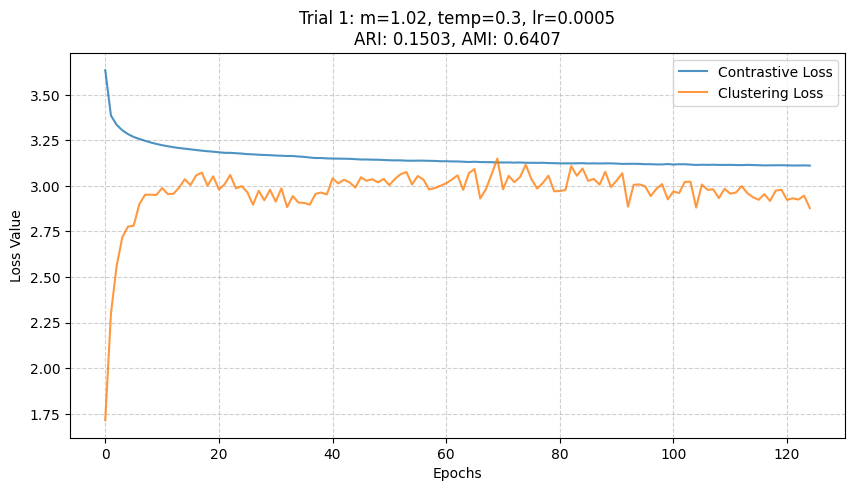

ARI: 0.1503
AMI: 0.6407
DONE!!!


In [17]:
num_combos = len(combinations)
# ground truth labels from metadata
y_true = metadata['label'].values

best_ari = -1.0
best_ami = -1.0
results = []
epochs = 125

print("HP Tuning started")
start_time = time.time()
for i in range(num_combos):
    print(f"COMBINATION {i}: ")
    hps = combinations[i]
    print(f"HYPERPARAMETERS: {hps}")
    history = {
        'contrastive': [],
        'clustering': []
    }

    # Init model, optimizer, loss, and scaler
    my_backbone = TwitterBackbone(input_dim=input_dim, rep_dim=feature_dim)
    model = Network(my_backbone, my_backbone.rep_dim, class_dim=num_events).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hps['lr'], weight_decay=hps['wd'])
    criterion = InfonceLoss(batch_size=batch_size, temperature=hps['temp'], device=device).to(device)
    scaler = torch.cuda.amp.GradScaler()

    # TRAINING LOOP
    for epoch in tqdm(range(epochs)):
        # Run 1 full pass thru Twitter data
        losses = train_model(model, ins_loader, optimizer, criterion, scaler, device, m=hps["m"])
        history['contrastive'].append(losses['loss1'])
        history['clustering'].append(losses['loss2'])
        
        # Print progress every 25 epochs
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Contrastive Loss: {losses['loss1']:.4f} | Clustering Loss: {losses['loss2']:.4f}")
    # Training is DONE
    
    # EVALUATION
    model.eval()
    with torch.no_grad():
        # Clustering
        _, probs = model.test_forward(embeddings)
        preds = torch.argmax(probs, dim=1).cpu().numpy()

    # Calculate Metrics
    ari = adjusted_rand_score(y_true, preds)
    ami = adjusted_mutual_info_score(y_true, preds)

    # Save Metrics
    results.append({**hps, 'ari': ari, 'ami': ami})

    # Update and Save Best if necessary
    is_new_best = False
    save_path = None
    if ari > best_ari:
        best_ari = ari
        print(f"NEW BEST ARI!!!")
        is_new_best = True
    if ami > best_ami:
        best_ami = ami
        print(f"NEW BEST AMI!!!")
        is_new_best = True

    if is_new_best:
        # Save the state_dict and hyperparameters
        m_str = str(hps["m"]).replace('.', '_')
        lr_str = str(hps["lr"]).replace('.', '_')
        wd_str = str(hps["wd"]).replace('.', '_')
        temp_str = str(hps["temp"]).replace('.', '_')
        save_path = f'plots/loss_curves_m{m_str}_lr{lr_str}_wd{wd_str}_temp{temp_str}.png'

    plot_loss_curves(history, i, hps, ari, ami, save_path=None)

    if is_new_best:
        model_save_path = f'models/event2012_DPAC_m_{m_str}_lr_{lr_str}_wd_{wd_str}_temp{temp_str}.tar'    
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'hps': hps,
            'num_events': num_events,
            'ari': ari,
            'ami': ami
        }, model_save_path)

    plt.show()
    # Adjusted Rand Index
    print(f"ARI: {ari:.4f}")
    # Adjusted Mutual Information
    print(f"AMI: {ami:.4f}")
    
end_time = time.time()
print("DONE!!!")
training_duration = end_time - start_time
time_in_minutes_and_seconds = convert(training_duration)

In [18]:
print(f"Time taken: {time_in_minutes_and_seconds}")

print(f"Best ARI Found: {best_ari:.4f}")
print(f"Best AMI Found: {best_ami:.4f}")

Time taken: 0:22:18
Best ARI Found: 0.1503
Best AMI Found: 0.6407


In [19]:
# # Save the state_dict and hyperparameters
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'hps': hps,
#     'num_events': num_events
# }, model_save_path)

# print(f"Model saved successfully to {model_save_path}")

# Evaluation

In [20]:
# # Inference (No gradients needed)
# with torch.no_grad():
#     # test_forward returns (features, probabilities)
#     _, probs = model.test_forward(embeddings)
    
#     # Get cluster index with highest probability
#     preds = torch.argmax(probs, dim=1).cpu().numpy()

# # Get ground truth labels from metadata
# y_true = metadata['label'].values

# print(f"Clustering finished for {len(preds)} tweets.")

In [21]:
# # Calculate Metrics
# ari = adjusted_rand_score(y_true, preds)
# ami = adjusted_mutual_info_score(y_true, preds)

# print(f"ARI (Adjusted Rand Index): {ari:.4f}")
# print(f"AMI (Adjusted Mutual Information): {ami:.4f}")

# BASELINE:
# ARI: 0.63
# AMI: 0.86

# ARI measures how many pairs of tweets are correctly grouped together or correctly separated. 
# AMI measures how much info is shared between my clusters and the true events. 

In [22]:
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset-name', default='cifar10',
#                     help='dataset name',
#                     choices=['stl10', 'cifar10', 'cifar100', 'imagenet10', 'imagenet_dogs', 'tiny_imagenet'])
# parser.add_argument('-data', metavar='DIR', default='./datasets',
#                     help='path to dataset')
# parser.add_argument('-model-path', default='./save/CIFAR-10',
#                     help='path to save model')
# # Training Hyper parameter
# parser.add_argument('--epochs', default=200, type=int, metavar='N',
#                     help='number of total epochs to run')
# parser.add_argument('-b', '--batch-size', default=256, type=int,
#                     metavar='N',
#                     help='mini-batch size (default: 240), this is the total '
#                          'batch size of all GPUs on the current node when '
#                          'using Data Parallel or Distributed Data Parallel')
# parser.add_argument('--lr', '--learning-rate', default=1e-4, type=float,
#                     metavar='LR', help='initial learning rate', dest='lr')
# parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
#                     metavar='W', help='weight decay (default: 1e-4)',
#                     dest='weight_decay')
# parser.add_argument('--resnet', default='ResNet34', help='Choice resnet.')

# # Hyper parameter
# parser.add_argument('--temperature', default=0.5, type=float, help='softmax temperature (default: 0.5)')
# parser.add_argument('--m', default=1.03, type=float, help='weight exponent > 1 (default: 1.03)')
# parser.add_argument('--thd', default=0.99, type=float, help='threshold of pseudo label (default: 0.95)')

# # Deployment
# parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')
# parser.add_argument('--seed', default=0, type=int)


# # NEW!!! I ADDED THIS!!!
# def kldiv(q, p):
#     """
#     Standard KL Divergence for clustering.
#     q: Target distribution (sharpened)
#     p: Predicted distribution
#     """
#     res = -torch.sum(q * torch.log(p + 1e-8), dim=-1)
#     return res.mean()
    

# def pac_loss(p, f):
#     N, C = p.shape
#     p = F.softmax(p, dim=1)
#     dis = 1 - 1 * torch.matmul(f, f.T)
#     ps = torch.mm(p, p.T)
#     loss = (dis * ps).sum(1)
#     return loss.sum() / N


# def model(args, ins_loader, optimizer, criterion, model, scaler):
#     loss_epoch = {'loss1': 0, 'loss2': 0, 'loss3': 0}
#     for step, ((weak, strong, ori), _) in enumerate(ins_loader):
#         weak = weak.to(args.device)
#         strong = strong.to(args.device)
#         img = torch.cat((weak, strong), dim=0)
#         ori = ori.to(args.device)
#         optimizer.zero_grad()
#         with torch.cuda.amp.autocast():
#             z, p1, u2 = model(img)
#             q, p = model.PAC_online(ori, m=args.m)  # clustering codes
#             # loss1 = criterion(z, p)  # contrastive learning
#             loss1 = criterion(z)
#             loss2 = kldiv(q, p1)  # online clustering
#             """ self-labeling fine-tuning same as Fixmatch"""
#             # max_probs, tragets_p = torch.max(F.softmax(p1, dim=1), dim=-1)  # pseudo labels
#             # mask = max_probs.ge(args.thd).float()
#             # loss3 = (F.cross_entropy(u2, tragets_p, reduction='none') * mask).mean()  # self-labeling
#             loss = loss1 + loss2
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#         loss_epoch['loss1'] += loss1.item() / len(ins_loader)
#         loss_epoch['loss2'] += loss2.item() / len(ins_loader)
#         # loss_epoch['loss3'] += loss3.item() / len(ins_loader)
#     return model, loss_epoch


# def main():
#     """ DPAC """
#     args = parser.parse_args()
#     args.device = torch.device(f'cuda:{args.gpu_index}')
#     torch.cuda.set_device(args.gpu_index)
#     print(f'select device:cuda{args.gpu_index}')
#     torch.manual_seed(args.seed)
#     torch.cuda.manual_seed_all(args.seed)
#     torch.cuda.manual_seed(args.seed)
#     np.random.seed(args.seed)

#     dataset = ContrastiveLearningDataset(args.data)
#     ins_dataset, class_num = dataset.get_dataset(args.dataset_name, dataset=True)
#     ins_loader = DataLoader(ins_dataset, batch_size=args.batch_size, shuffle=True, pin_memory=True,
#                                   num_workers=4, drop_last=True)
#     if args.dataset_name == 'cifar10' or args.dataset_name == 'cifar100':
#         res = get_resnet_cifar(args.resnet)
#     elif args.dataset_name == 'stl10':
#         res = get_resnet_stl(args.resnet)
#     else:
#         res = get_resnet(args.resnet)
#     model = Network(res, res.rep_dim, class_num)
#     model = model.to(args.device)
#     checkpoint = torch.load('./save/CL_1000.tar', map_location=args.device)
#     model.load_state_dict(checkpoint['net'], strict=False)
#     optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-4)
#     criterion = InfonceLoss(args.batch_size, args.temperature, args.device).to(args.device)
#     torch.backends.cudnn.benchmark = True
#     torch.backends.cuda.matmul.allow_tf32 = True
#     torch.backends.cudnn.allow_tf32 = True
#     scaler = torch.cuda.amp.GradScaler()

#     for epoch_counter in tqdm(range(args.epochs)):
#         model, loss_epoch = model(args, ins_loader, optimizer, criterion, model, scaler)
#         print(
#             f"Epoch [{epoch_counter}/{args.epochs}]\t "
#             f"loss1_epoch: {loss_epoch['loss1']}\t "
#             f"loss2_epoch: {loss_epoch['loss2']}\t "
#             f"loss3_epoch: {loss_epoch['loss3']}\t "
#         )
#         save_model(args, model, optimizer)


# if __name__ == '__main__':
#     main()
